In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

produtos = {
    "A Revolução dos Bichos": ("Política", 28.50),
    "O Hobbit":              ("Fantasia", 55.90),
    "1984":                  ("Ficção", 34.90),
    "Inteligência Artificial": ("Tecnologia", 120.00),
    "Banco de Dados Essencial": ("Tecnologia", 75.00),
    "Percy Jackson Vol.1":   ("Aventura", 42.90),
    "Mindset":               ("Psicologia", 39.90),
    "Meditações":            ("Filosofia", 27.00),
    "Uma Breve História do Tempo": ("Ciência", 65.00),
    "Orgulho e Preconceito": ("Romance", 31.90),
}

vendedores = ["Juliana Souza", "Rafael Alves", "Patrícia Gomes", "Lucas Martins"]
regioes    = ["Leste", "Oeste", "Interior", "Litoral", "Capital"]
datas      = pd.date_range("2023-07-01", "2023-12-31", periods=50)

nomes_prod = np.random.choice(list(produtos.keys()), 50)

dados = {
    "id_venda":   range(1, 51),
    "data":       datas.strftime("%Y-%m-%d"),
    "produto":    nomes_prod,
    "categoria":  [produtos[p][0] for p in nomes_prod],
    "quantidade": np.random.randint(1, 6, 50),
    "preco_unit": [produtos[p][1] for p in nomes_prod],
    "vendedor":   np.random.choice(vendedores, 50),
    "regiao":     np.random.choice(regioes, 50),
}

df = pd.DataFrame(dados)
df["total_venda"] = df["quantidade"] * df["preco_unit"]

df.to_csv("vendas_livraria_novo.csv", index=False)

print(f"✅ Dataset criado! Shape: {df.shape}")
print(f"   Colunas: {list(df.columns)}")
df.head()

✅ Dataset criado! Shape: (50, 9)
   Colunas: ['id_venda', 'data', 'produto', 'categoria', 'quantidade', 'preco_unit', 'vendedor', 'regiao', 'total_venda']


,id_venda,data,produto,categoria,quantidade,preco_unit,vendedor,regiao,total_venda
0,1,2023-07-01,Mindset,Psicologia,3,39.9,Juliana Souza,Capital,119.7
1,2,2023-07-04,Inteligência Artificial,Tecnologia,1,120.0,Lucas Martins,Litoral,120.0
2,3,2023-07-08,Meditações,Filosofia,4,27.0,Patrícia Gomes,Capital,108.0
3,4,2023-07-12,Banco de Dados Essencial,Tecnologia,2,75.0,Patrícia Gomes,Interior,150.0
4,5,2023-07-15,Mindset,Psicologia,4,39.9,Rafael Alves,Interior,159.6


In [ ]:
df = pd.read_csv("vendas_livraria_novo.csv")

print("═" * 45)
print("📋 INFORMAÇÕES DO DATASET")
print("═" * 45)
print(f"Linhas:   {df.shape[0]}")
print(f"Colunas:  {df.shape[1]}")

print("\n📊 TIPOS DE DADOS:")
print(df.dtypes)

print("\n🔍 VALORES NULOS:")
print(df.isnull().sum())

print("\n📈 ESTATÍSTICAS DESCRITIVAS:")
df[["quantidade", "preco_unit", "total_venda"]].describe().round(2)

═════════════════════════════════════════════
📋 INFORMAÇÕES DO DATASET
═════════════════════════════════════════════
Linhas:   50
Colunas:  9

📊 TIPOS DE DADOS:
id_venda         int64
data            object
produto         object
categoria       object
quantidade       int64
preco_unit     float64
vendedor        object
regiao          object
total_venda    float64
dtype: object

🔍 VALORES NULOS:
id_venda       0
data           0
produto        0
categoria      0
quantidade     0
preco_unit     0
vendedor       0
regiao         0
total_venda    0
dtype: int64

📈 ESTATÍSTICAS DESCRITIVAS:


,quantidade,preco_unit,total_venda
count,50.00,50.00,50.00
mean,2.84,53.81,145.49
std,1.45,27.55,103.58
min,1.00,27.00,31.90
25%,2.00,32.65,66.20
50%,3.00,41.40,132.50
75%,4.00,65.00,170.62
max,5.00,120.00,600.00


In [ ]:
# ── Análise de Vendas ────────────────────────────────

# 1. Total faturado
total = df["total_venda"].sum()
print(f"💰 Faturamento Total: R$ {total:,.2f}")

# 2. Faturamento por categoria
print("\n📦 Faturamento por Categoria:")
cat_fat = (df.groupby("categoria")["total_venda"]
             .sum()
             .sort_values(ascending=False))
print(cat_fat.apply(lambda x: f"R$ {x:,.2f}"))

# 3. Melhor vendedor
print("\n🏆 Ranking de Vendedores:")
vend_rank = (df.groupby("vendedor")["total_venda"]
               .sum()
               .sort_values(ascending=False))
print(vend_rank.apply(lambda x: f"R$ {x:,.2f}"))

# 4. Produto mais vendido (em quantidade)
print("\n📚 Top 3 Produtos (qtd vendida):")
top_prod = (df.groupby("produto")["quantidade"]
              .sum()
              .sort_values(ascending=False)
              .head(3))
print(top_prod)

# 5. Venda média por região
print("\n🗺️  Ticket Médio por Região:")
reg_media = (df.groupby("regiao")["total_venda"]
               .mean()
               .sort_values(ascending=False)
               .round(2))
print(reg_media.apply(lambda x: f"R$ {x:,.2f}"))

💰 Faturamento Total: R$ 7,274.70

📦 Faturamento por Categoria:
categoria
Tecnologia    R$ 2,790.00
Psicologia      R$ 997.50
Fantasia        R$ 726.70
Ciência         R$ 715.00
Filosofia       R$ 594.00
Aventura        R$ 557.70
Romance         R$ 478.50
Ficção          R$ 244.30
Política        R$ 171.00
Name: total_venda, dtype: object

🏆 Ranking de Vendedores:
vendedor
Patrícia Gomes    R$ 3,234.80
Juliana Souza     R$ 1,532.40
Lucas Martins     R$ 1,426.00
Rafael Alves      R$ 1,081.50
Name: total_venda, dtype: object

📚 Top 3 Produtos (qtd vendida):
produto
Mindset                     25
Meditações                  22
Banco de Dados Essencial    18
Name: quantidade, dtype: int64

🗺️  Ticket Médio por Região:
regiao
Interior    R$ 182.39
Litoral     R$ 145.99
Leste       R$ 137.51
Capital     R$ 131.01
Oeste       R$ 125.92
Name: total_venda, dtype: object


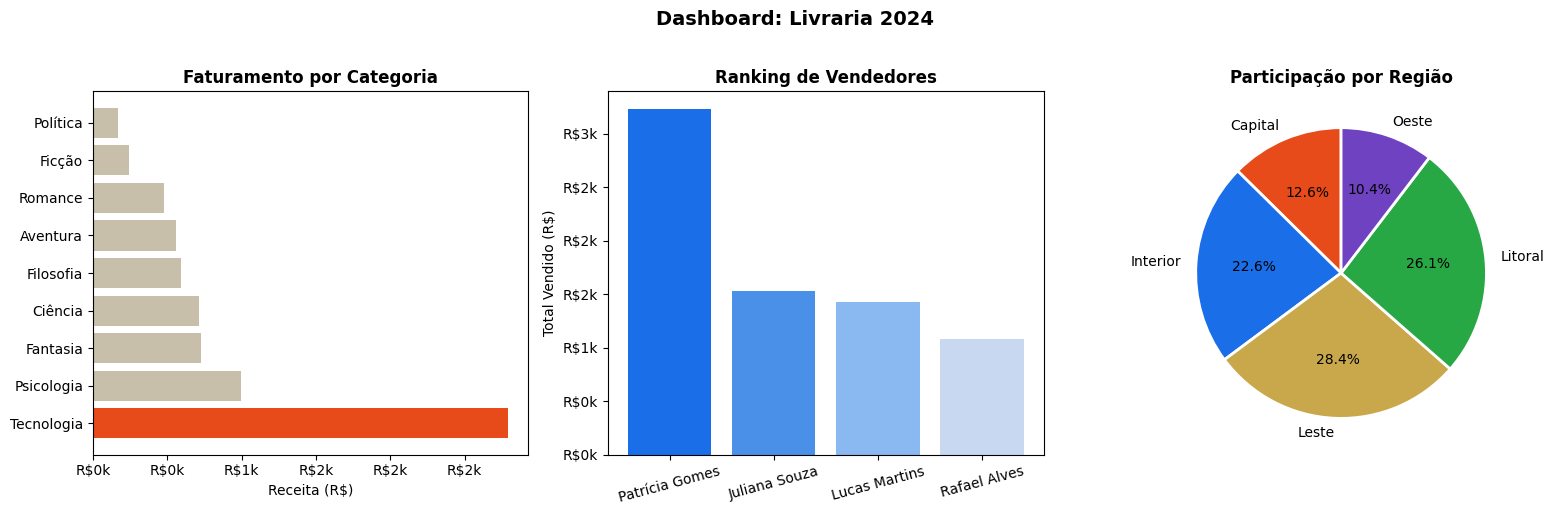

✅ Gráficos salvos em dashboard_livraria.png


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Dashboard: Livraria 2024",
             fontsize=14, fontweight="bold", y=1.02)

ax1 = axes[0]
cores = ["#e84b1a" if i==0 else "#c8bfaa" for i in range(len(cat_fat))]
ax1.barh(cat_fat.index, cat_fat.values, color=cores)
ax1.set_title("Faturamento por Categoria", fontweight="bold")
ax1.set_xlabel("Receita (R$)")
ax1.xaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"R${x/1000:.0f}k"))

ax2 = axes[1]
ax2.bar(vend_rank.index, vend_rank.values,
        color=["#1a6ee8","#4a90e8","#8ab8f0","#c8d8f0"])
ax2.set_title("Ranking de Vendedores", fontweight="bold")
ax2.set_ylabel("Total Vendido (R$)")
ax2.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda y, _: f"R${y/1000:.0f}k"))
ax2.tick_params(axis="x", rotation=15)

ax3 = axes[2]
reg_total = df.groupby("regiao")["total_venda"].sum()
ax3.pie(reg_total, labels=reg_total.index,
        autopct="%1.1f%%",
        colors=["#e84b1a","#1a6ee8","#c9a84c","#28a745","#6f42c1"],
        startangle=90,
        wedgeprops={"edgecolor":"white", "linewidth":2})
ax3.set_title("Participação por Região", fontweight="bold")

plt.tight_layout()
plt.savefig("dashboard_livraria.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Gráficos salvos em dashboard_livraria.png")

DESAFIO 1

In [ ]:
df["data"] = pd.to_datetime(df["data"])

In [ ]:
df["mes"] = df["data"].dt.month

In [ ]:
fat_mensal = df.groupby("mes")["total_venda"].sum()
print(fat_mensal)

mes
7     1085.5
8     1149.3
9     1356.8
10    1282.8
11    1247.1
12    1153.2
Name: total_venda, dtype: float64


DESAFIO 2

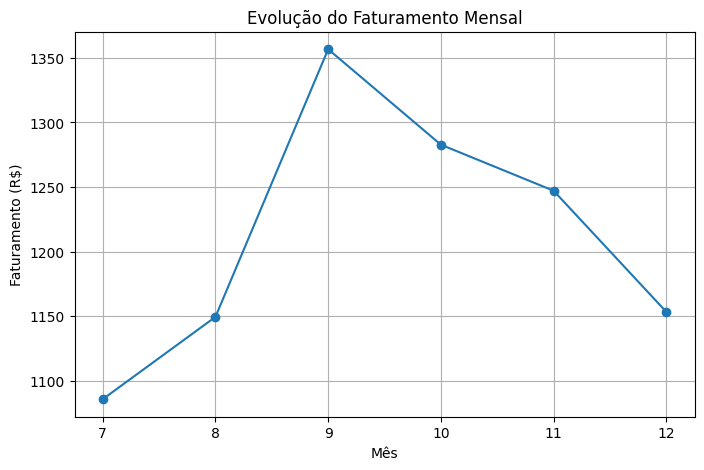

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(fat_mensal.index, fat_mensal.values, marker="o")

plt.title("Evolução do Faturamento Mensal")
plt.xlabel("Mês")
plt.ylabel("Faturamento (R$)")

plt.grid()

plt.show()

DESAFIO 3

In [ ]:
ticket_medio = df.groupby("vendedor")["total_venda"].mean().sort_values(ascending=False)

print("💰 Ticket médio por vendedor:")
print(ticket_medio)

print("\n🏆 Melhor vendedor (ticket médio):")
print(ticket_medio.head(1))

💰 Ticket médio por vendedor:
vendedor
Lucas Martins     158.444444
Patrícia Gomes    154.038095
Rafael Alves      135.187500
Juliana Souza     127.700000
Name: total_venda, dtype: float64

🏆 Melhor vendedor (ticket médio):
vendedor
Lucas Martins    158.444444
Name: total_venda, dtype: float64


DESAFIO 4

In [ ]:
altas_vendas = df[df["total_venda"] > 200]

In [ ]:
cat_altas = altas_vendas["categoria"].value_counts()

print("📦 Categorias com vendas altas:")
print(cat_altas)

📦 Categorias com vendas altas:
categoria
Tecnologia    6
Aventura      1
Ciência       1
Fantasia      1
Name: count, dtype: int64


DESAFIO 5

In [ ]:
linhas_nulas = pd.DataFrame({
    "id_venda": [None]*5,
    "data": [None]*5,
    "produto": [None]*5,
    "categoria": [None]*5,
    "quantidade": [None]*5,
    "preco_unit": [None]*5,
    "vendedor": [None]*5,
    "regiao": [None]*5,
    "total_venda": [None]*5
})

df = pd.concat([df, linhas_nulas], ignore_index=True)

/tmp/ipykernel_478/1512105621.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, linhas_nulas], ignore_index=True)


In [ ]:
print("Valores nulos por coluna:")
print(df.isnull().sum())

Valores nulos por coluna:
id_venda       5
data           5
produto        5
categoria      5
quantidade     5
preco_unit     5
vendedor       5
regiao         5
total_venda    5
mes            5
dtype: int64
